In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

In [7]:
data_path = r"C:\Users\shubh\Documents\Customer Churn\DataSet\WA_Fn-UseC_-Telco-Customer-Churn.csv"

data = pd.read_csv(data_path)

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data.dropna(subset=['TotalCharges'], inplace=True)
data['Churn'] = (data['Churn'] == "Yes").astype(int)

data['tenure_group'] = pd.cut(
    data['tenure'], 
    bins=[0, 12, 24, 48, 60, 72], 
    labels=['0-12','13-24','25-48','49-60','61-72']
)
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-48
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12



VISUALISATION

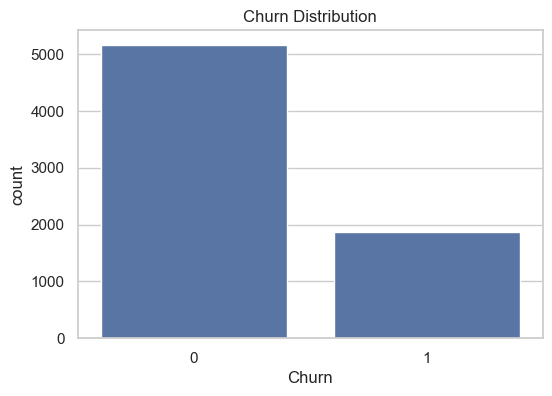

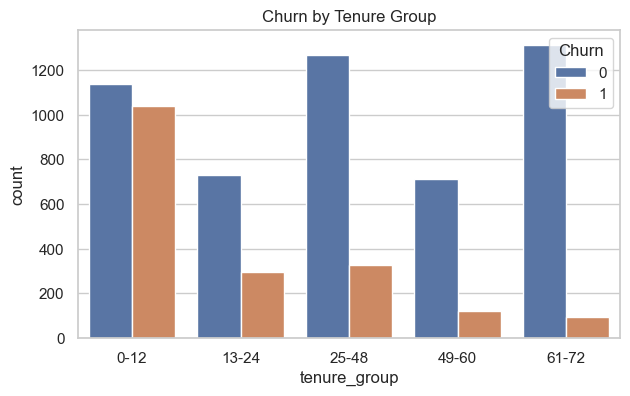

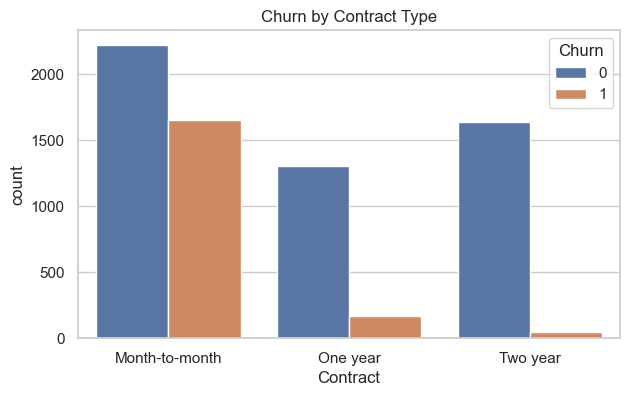

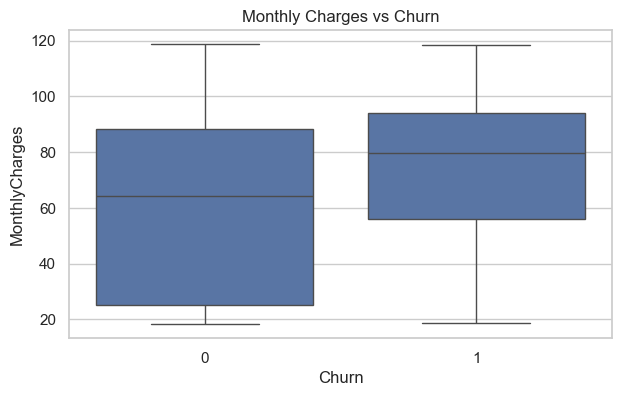

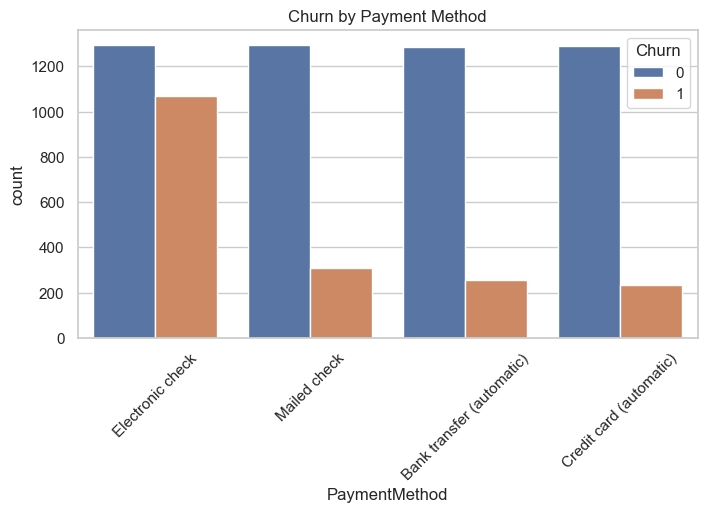

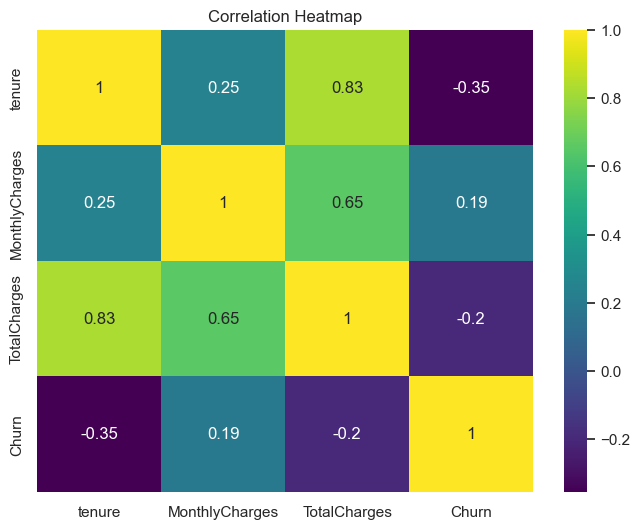

In [3]:
sns.set_theme(style="whitegrid")

# Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=data)
plt.title("Churn Distribution")
plt.show()

# Churn vs Tenure Group
plt.figure(figsize=(7,4))
sns.countplot(x='tenure_group', hue='Churn', data=data)
plt.title("Churn by Tenure Group")
plt.show()

# Churn vs Contract
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=data)
plt.title("Churn by Contract Type")
plt.show()

# Monthly Charges vs Churn
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title("Monthly Charges vs Churn")
plt.show()

# Churn vs Payment Method
plt.figure(figsize=(8,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=data)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    data[['tenure','MonthlyCharges','TotalCharges','Churn']].corr(),
    annot=True, cmap='viridis'
)
plt.title("Correlation Heatmap")
plt.show()


FEATURE SETUP


In [4]:
X = data.drop(['customerID', 'Churn'], axis=1)
y = data['Churn']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

PREPROCESSING PIPELINE

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

FIX CLASS IMBALANCE (SMOTE)

In [8]:
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train_prep, y_train)

LIGHTGBM

In [9]:
param_grid = {
    'n_estimators': [300, 500],
    'learning_rate': [0.03, 0.05],
    'max_depth': [6, 8],
    'num_leaves': [31, 50]
}

grid = GridSearchCV(
    lgb.LGBMClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)

model = grid.best_estimator_



[LightGBM] [Info] Number of positive: 4130, number of negative: 4130
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4808
[LightGBM] [Info] Number of data points in the train set: 8260, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [10]:
y_pred = model.predict(X_test_prep)
y_proba = model.predict_proba(X_test_prep)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("AUC Score:", roc_auc_score(y_test, y_proba))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1033
           1       0.60      0.61      0.60       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407

AUC Score: 0.8226403031510942


c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
